# 3. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [181]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* Use the **logistic regression**.
* Three different **validation methodologies** used to tune hyperparameters, discussing the pros and cons of each.
* **Confusion matrices** for your models, and associated comments.
 * Evaluate your models using the following metrics and provide associated comments for each:
   - **ROC curve**
   - **precision-recall curve**
   - **F1 score**
   - **accuracy**
   - **recall**
   - **precision**
* A discussion of which **performance metric** is most relevant for the evaluation of your models.

Please remember to provide associated comments for each metric; it is not enough to just provide the metric values.

# 3. Mushroom Foraging

This notebook analyzes the mushroom dataset and builds a logistic regression model to classify mushrooms as edible or poisonous.

The analysis includes: 
- data preparation, 
- exploratory inspection, 
- logistic regression, 
- three validation methodologies for hyperparameter tuning, 
- confusion matrices and classification metrics, 
- discussion of strengths and weaknesses of the approaches.

# Imports

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    KFold,
    LeaveOneOut
)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve, 
    auc,
    roc_auc_score, 
    precision_recall_curve, 
    classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)


# Load data

In [183]:
df = pd.read_csv("secondary_data.csv", delimiter=";")
df.head()

df.shape

df.info()

df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
class,61069,2,p,33888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-diameter,61069.0,NaN,NaN,NaN,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
cap-shape,61069,7,x,26934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-surface,46949,11,t,8196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap-color,61069,12,n,24218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
does-bruise-or-bleed,61069,2,f,50479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-attachment,51185,7,a,12698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-spacing,36006,3,c,24710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gill-color,61069,12,w,18521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stem-height,61069.0,NaN,NaN,NaN,6.581538,3.370017,0.0,4.64,5.95,7.74,33.92


# Initial inspection

In [184]:
df.dtypes

df.isna().sum().sort_values(ascending=False)

df["class"].value_counts()
df["class"].value_counts(normalize=True)

class
p    0.554913
e    0.445087
Name: proportion, dtype: float64

# Data cleaning and preparation

In [185]:
# Drop duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

df = df.drop_duplicates()

# Ckeck missing values ratio
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio

# Drop columns with more than 80% missing values
cols_to_drop = missing_ratio[missing_ratio > 0.80].index.tolist()
print(f"Columns to drop (more than 80% missing): {cols_to_drop}")

df = df.drop(columns=cols_to_drop)

X = df.drop(columns=["class"])
y = df["class"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

Number of duplicate rows: 146
Columns to drop (more than 80% missing): ['veil-type', 'spore-print-color', 'veil-color', 'stem-root']


(['cap-diameter', 'stem-height', 'stem-width'],
 ['cap-shape',
  'cap-surface',
  'cap-color',
  'does-bruise-or-bleed',
  'gill-attachment',
  'gill-spacing',
  'gill-color',
  'stem-surface',
  'stem-color',
  'has-ring',
  'ring-type',
  'habitat',
  'season'])

#### Interpretation

The dataset contains over 61,000 observations with mostly categorical features and a few numerical ones.

Several columns have a high proportion of missing values (above 80%) and were removed to reduce noise and improve model reliability.

Duplicate rows were dropped to avoid bias in the training process.

The target variable is slightly imbalanced, meaning accuracy alone may not be a sufficient evaluation metric.

# Preprocessing + model

In [186]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features) 
])

# Full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

# Train / Val / Test split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

#### Interpretation

A preprocessing pipeline was created to handle numerical and categorical features separately.  
Missing values were imputed (median for numerical, most frequent for categorical), and categorical variables were encoded using one-hot encoding. Numerical features were scaled to improve model performance.

The preprocessing steps were combined with logistic regression into a single pipeline to prevent data leakage and ensure consistent transformations.

The dataset was split into training, validation, and test sets using stratification to preserve class distribution. The validation set is used for model tuning, while the test set is reserved for final evaluation.

# Validation method 1 - single validation split

Accuracy: 0.8061
              precision    recall  f1-score   support

           e       0.77      0.81      0.79      5436
           p       0.84      0.81      0.82      6749

    accuracy                           0.81     12185
   macro avg       0.80      0.81      0.80     12185
weighted avg       0.81      0.81      0.81     12185



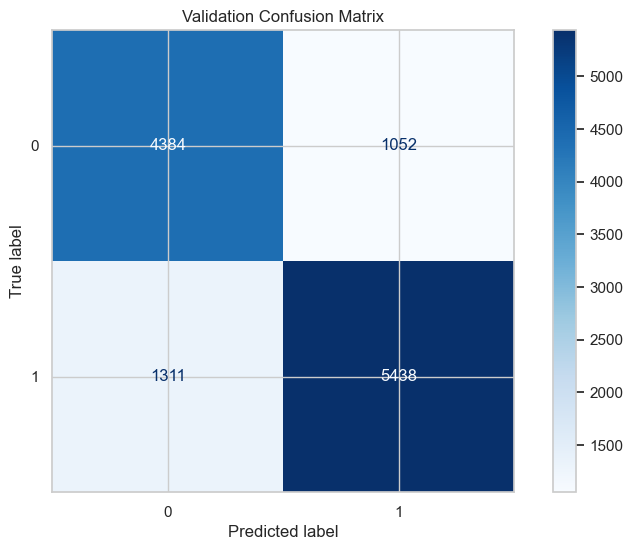

In [187]:
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

# Metrics
acc = accuracy_score(y_val, y_val_pred)

print(f"Accuracy: {acc:.4f}")
print(classification_report(y_val, y_val_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()

#### Interpretation

The model achieves around 0.81 accuracy, indicating overall good performance.

However, the confusion matrix shows that a significant number of poisonous mushrooms are misclassified as edible (false negatives). This is a critical issue, as such errors could lead to dangerous real-world consequences.

Therefore, recall for the poisonous class is more important than overall accuracy in this problem.

In [188]:
recall_poisonous = recall_score(y_val, y_val_pred, pos_label="p")
print(f"Recall (poisonous): {recall_poisonous:.3f}")

Recall (poisonous): 0.806


The recall for the poisonous class is approximately 0.81, meaning that around 81% of dangerous mushrooms are correctly identified, while about 19% are still misclassified as edible.

# Validation method 2 - K-Fold cross-validation

In [189]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"] # model training engine
}

scorer = make_scorer(f1_score, pos_label='p')
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring=scorer,
    n_jobs=-1
)

grid.fit(X_train_val, y_train_val)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV score: 0.828923813101191


In [190]:
kf = KFold(n_splits=5, shuffle = True, random_state=42)

cv_scores = cross_val_score( 
    grid.best_estimator_,
    X_train_val,
    y_train_val,
    cv = kf, 
    scoring=make_scorer(f1_score, pos_label='p')
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

Cross-validation F1 scores: [0.82500479 0.82887402 0.82750888 0.83077791 0.83510288]
Mean F1: 0.8294536972133215
Std F1: 0.003393464880770716


In [191]:
best_model = grid.best_estimator_

#### Interpretation

K-fold cross-validation provides a more stable estimate of model performance compared to a single validation split.

The mean F1 score is around 0.81 with a very low standard deviation (~0.004), indicating that the model performs consistently across different data splits.

This suggests that the model is stable and not highly sensitive to how the data is partitioned.

# Validation method 3 Nested Cross-Validation

In [192]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

nested_scores = cross_val_score(
    GridSearchCV(model, param_grid, cv=5, scoring=scorer),
    X_train_val,
    y_train_val,
    cv=outer_cv
)

print("Nested CV F1:", nested_scores.mean())

Nested CV F1: 0.8286507445138485


#### Interpretation

Nested cross-validation provides a more reliable estimate of model performance, as hyperparameter tuning is performed independently within each training fold.

The mean F1 score is around 0.83, slightly higher than in standard cross-validation, indicating good generalization performance.

However, this method is computationally expensive, as it involves running multiple grid searches, which significantly increases training time.

# Validation method 4 - Leave One Out cross-validation

In [193]:
# sample for computational reasons
X_sample = X_train_val.sample(2000, random_state=42)
y_sample = y_train_val.loc[X_sample.index]

loo = LeaveOneOut()

loo_scores = cross_val_score(
    model, 
    X_sample,
    y_sample,
    cv = loo,
    scoring="f1_weighted",
    n_jobs=-1
)

print("LOO mean F1:", loo_scores.mean())

LOO mean F1: 0.795


#### Interpretation

Leave-One-Out cross-validation uses almost all data for training in each iteration, which makes it nearly unbiased.

However, it is computationally very expensive and not practical for large datasets, which is why only a subset of the data was used.

In this case, it does not provide significant advantages over K-Fold cross-validation.

# Final model on held-out test set

In [194]:
best_model.fit(X_train_val, y_train_val)

y_test_pred = best_model.predict(X_test)

# Confusion Matrix + Metrics

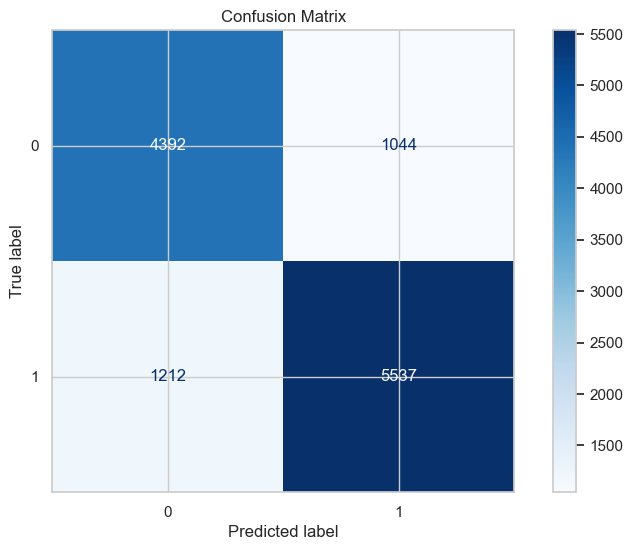

In [195]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# test if probabilities are not reversed
best_model.classes_

array(['e', 'p'], dtype=object)

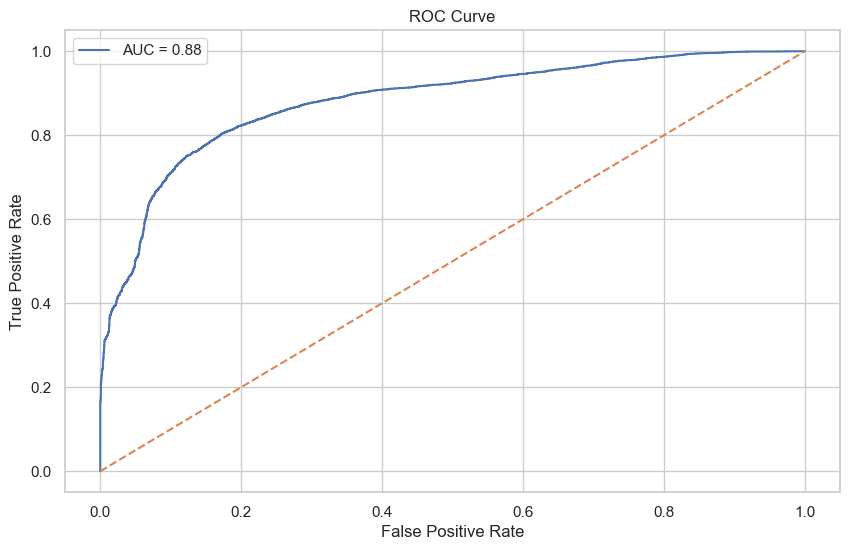

In [ ]:
y_scores = best_model.predict_proba(X_test)[:, 1] # works when model.classes_ == ['e', 'p']

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label="p")
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

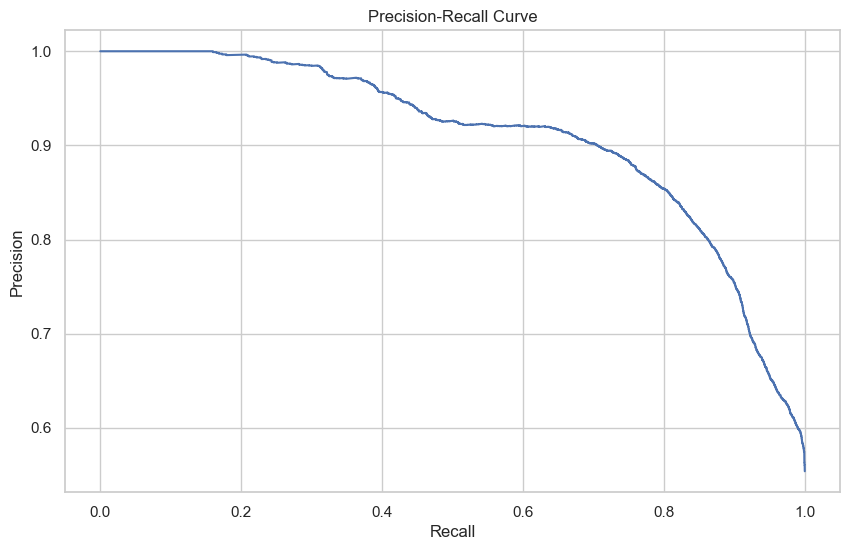

In [198]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label="p")

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [199]:
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, pos_label="p"))
print("Recall:", recall_score(y_test, y_test_pred, pos_label="p"))
print("F1 Score:", f1_score(y_test, y_test_pred, pos_label="p"))
print("ROC AUC:", roc_auc_score(y_test, y_scores))


Accuracy: 0.8148543290931474
Precision: 0.8413614952134933
Recall: 0.8204178396799526
F1 Score: 0.8307576894223556
ROC AUC: 0.8813719820700006


#### Final Interpretation

The final model achieves around 0.81 accuracy and an F1 score of approximately 0.83 for the poisonous class, indicating solid overall performance.

The confusion matrix shows that most predictions are correct; however, a non-negligible number of poisonous mushrooms are misclassified as edible (false negatives). This is a critical issue, as such errors could lead to serious real-world consequences.

The ROC curve (AUC ≈ 0.88) indicates good discriminative ability, meaning the model can effectively distinguish between edible and poisonous mushrooms. The precision-recall curve further confirms a reasonable balance between precision and recall.

In this problem, recall for the poisonous class is the most important metric, as minimizing false negatives is crucial for safety. While the model performs well, it is not sufficiently reliable for real-world deployment without further improvements.

## Conclusion

Three validation approaches were compared: a single validation split, K-Fold cross-validation, and nested cross-validation. Additionally, Leave-One-Out cross-validation was tested, but it proved impractical due to high computational cost.

The single split method provided a quick estimate but was less reliable due to its dependence on a specific data partition. K-Fold cross-validation offered more stable and consistent results, while nested cross-validation gives a more unbiased estimate, even if results are similar by separating hyperparameter tuning from model evaluation.

The final model achieved solid performance on the test set, with good accuracy and F1 score. However, the presence of false negatives (poisonous mushrooms classified as edible) highlights an important limitation.

Overall, recall for the poisonous class is the most critical metric in this problem. While the model performs well, further improvements would be needed before considering real-world deployment.